In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [3]:
df=pd.read_csv("E:\supervised learning\exm 03\Risk_Alert_Classifier_Dataset_4600 - Risk_Alert_Classifier_Dataset_4600.csv.csv")

<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\Admin\AppData\Local\Temp\ipykernel_8452\1573357358.py:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  df=pd.read_csv("E:\supervised learning\exm 03\Risk_Alert_Classifier_Dataset_4600 - Risk_Alert_Classifier_Dataset_4600.csv.csv")


In [4]:
df.describe()

,customer_id,age,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,debt_balance_inr,risk_status
count,4600.000000,4460.000000,4434.000000,4384.000000,4453.000000,4600.000000,4600.000000,4600.000000,4471.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,502300.500000,36.360314,41753.518268,677.784443,0.394721,0.924130,5.538696,65.030000,21511.273541,0.709783,0.443478,2.087174,53.744565,41143.328696,0.121087
std,1328.049949,10.670375,17740.750972,64.888787,0.205771,1.300018,5.624891,24.180762,10887.272864,1.020507,0.716546,1.621504,31.325334,26665.221097,0.326264
min,500001.000000,18.000000,15000.000000,405.000000,0.002000,0.000000,0.100000,5.000000,3769.000000,0.000000,0.000000,0.000000,2.000000,3653.000000,0.000000
25%,501150.750000,28.000000,28980.000000,638.000000,0.232000,0.000000,2.100000,49.000000,13422.500000,0.000000,0.000000,1.000000,31.000000,21302.750000,0.000000
50%,502300.500000,36.000000,38932.500000,682.000000,0.370000,1.000000,3.900000,65.000000,19317.000000,0.000000,0.000000,2.000000,48.000000,35638.500000,0.000000
75%,503450.250000,44.000000,51282.500000,721.250000,0.531000,1.000000,6.600000,81.000000,27147.000000,1.000000,1.000000,3.000000,70.000000,54274.250000,0.000000
max,504600.000000,75.000000,163002.000000,850.000000,0.978000,10.000000,47.100000,153.000000,87389.000000,7.000000,7.000000,12.000000,180.000000,213601.000000,1.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                4600 non-null   int64  
 1   age                        4460 non-null   float64
 2   gender                     4600 non-null   object 
 3   region                     4498 non-null   object 
 4   employment_type            4456 non-null   object 
 5   annual_income_inr          4434 non-null   float64
 6   credit_score               4384 non-null   float64
 7   credit_utilization_ratio   4453 non-null   float64
 8   missed_payments_12m        4600 non-null   int64  
 9   avg_late_payment_days      4600 non-null   float64
 10  monthly_transaction_count  4600 non-null   int64  
 11  monthly_spend_inr          4471 non-null   float64
 12  cash_advance_count_6m      4600 non-null   int64  
 13  complaints_last_6m         4600 non-null   int64

In [5]:
df.isnull().sum()

customer_id                    0
age                          140
gender                         0
region                       102
employment_type              144
annual_income_inr            166
credit_score                 216
credit_utilization_ratio     147
missed_payments_12m            0
avg_late_payment_days          0
monthly_transaction_count      0
monthly_spend_inr            129
cash_advance_count_6m          0
complaints_last_6m             0
failed_login_attempts_3m       0
account_tenure_months          0
last_transaction_date          0
debt_balance_inr               0
risk_status                    0
dtype: int64

#TASK


In [5]:




# Input Features (X)
X = df.drop("risk_status", axis=1)

# Target Variable (y)
y = df["risk_status"]

# Display input features
print("Input Features:")
print(X.columns)

# Display target variable
print("\nTarget Variable:")
print(y.name)

Input Features:
Index(['customer_id', 'age', 'gender', 'region', 'employment_type',
       'annual_income_inr', 'credit_score', 'credit_utilization_ratio',
       'missed_payments_12m', 'avg_late_payment_days',
       'monthly_transaction_count', 'monthly_spend_inr',
       'cash_advance_count_6m', 'complaints_last_6m',
       'failed_login_attempts_3m', 'account_tenure_months',
       'last_transaction_date', 'debt_balance_inr'],
      dtype='object')

Target Variable:
risk_status


In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split



# Input Features (X)
X = df.drop("risk_status", axis=1)

# Target Variable (y)
y = df["risk_status"]

# Train-Test Split (80% Train, 20% Test) while maintaining class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the shapes
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (3680, 18)
X_test shape : (920, 18)
y_train shape: (3680,)
y_test shape : (920,)


In [7]:
from sklearn.impute import KNNImputer

# Select numerical columns only
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Create KNN Imputer
knn_imputer = KNNImputer(n_neighbors=5)

# Apply KNN Imputer
df[num_cols] = knn_imputer.fit_transform(df[num_cols])

# Check missing values again
print("\nMissing Values After KNN Imputation:")
print(df[num_cols].isnull().sum())


Missing Values After KNN Imputation:
customer_id                  0
age                          0
annual_income_inr            0
credit_score                 0
credit_utilization_ratio     0
missed_payments_12m          0
avg_late_payment_days        0
monthly_transaction_count    0
monthly_spend_inr            0
cash_advance_count_6m        0
complaints_last_6m           0
failed_login_attempts_3m     0
account_tenure_months        0
debt_balance_inr             0
risk_status                  0
dtype: int64


#Part C


In [8]:


# Separate features and target
X = df.drop("risk_status", axis=1)
y = df["risk_status"]

# Encode categorical input features
X = pd.get_dummies(X, drop_first=True)

# Encode target variable
le = LabelEncoder()
y = le.fit_transform(y)

# Handle missing values using KNN Imputer
imputer = KNNImputer(n_neighbors=5)
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Logistic Regression Model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9891304347826086

Confusion Matrix:
[[805   4]
 [  6 105]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       809
           1       0.96      0.95      0.95       111

    accuracy                           0.99       920
   macro avg       0.98      0.97      0.97       920
weighted avg       0.99      0.99      0.99       920



c:\Users\Admin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Extract values
TN, FP, FN, TP = cm.ravel()

# Print results
print("Confusion Matrix:\n", cm)
print("\nTrue Negative (TN):", TN)
print("False Positive (Type I Error):", FP)
print("False Negative (Type II Error):", FN)
print("True Positive (TP):", TP)

Confusion Matrix:
 [[805   4]
 [  6 105]]

True Negative (TN): 805
False Positive (Type I Error): 4
False Negative (Type II Error): 6
True Positive (TP): 105


Part D

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Train model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9771739130434782
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       809
           1       0.92      0.89      0.90       111

    accuracy                           0.98       920
   macro avg       0.95      0.94      0.95       920
weighted avg       0.98      0.98      0.98       920



risk_status
0.0    4043
1.0     557
Name: count, dtype: int64


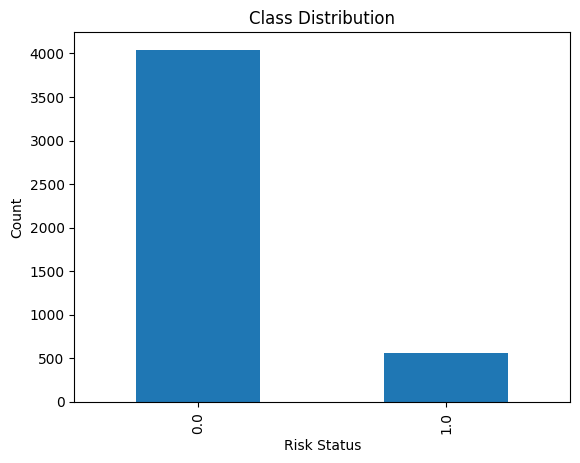

In [11]:
print(df['risk_status'].value_counts())

df['risk_status'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Risk Status")
plt.ylabel("Count")
plt.show()

In [13]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

In [14]:
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train_under, y_train_under)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.92      0.96       809
           1       0.63      0.95      0.76       111

    accuracy                           0.93       920
   macro avg       0.81      0.94      0.86       920
weighted avg       0.95      0.93      0.93       920



In [15]:
ros = RandomOverSampler(random_state=42)
X_train_over, y_train_over = ros.fit_resample(X_train, y_train)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train_over, y_train_over)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       809
           1       0.87      0.91      0.89       111

    accuracy                           0.97       920
   macro avg       0.93      0.95      0.94       920
weighted avg       0.97      0.97      0.97       920



In [16]:
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train_adasyn, y_train_adasyn)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       809
           1       0.87      0.87      0.87       111

    accuracy                           0.97       920
   macro avg       0.92      0.93      0.93       920
weighted avg       0.97      0.97      0.97       920



In [17]:
from sklearn.metrics import recall_score, f1_score, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))

Recall: 0.8738738738738738
F1 Score: 0.8699551569506726
AUC: 0.9276662323633893


In [ ]:
y_pred_smote = model.predict(X_test)
y_prob_smote = model.predict_proba(X_test)[:,1]

print("Recall:", recall_score(y_test, y_pred_smote))
print("F1 Score:", f1_score(y_test, y_pred_smote))
print("AUC:", roc_auc_score(y_test, y_prob_smote))


Recall: 0.8738738738738738
F1 Score: 0.8699551569506726
AUC: 0.9276662323633893


In [19]:
from sklearn.metrics import recall_score, f1_score, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))

Recall: 0.8738738738738738
F1 Score: 0.8699551569506726
AUC: 0.9276662323633893


In [20]:
y_pred_smote = model.predict(X_test)
y_prob_smote = model.predict_proba(X_test)[:,1]

print("Recall:", recall_score(y_test, y_pred_smote))
print("F1 Score:", f1_score(y_test, y_pred_smote))
print("AUC:", roc_auc_score(y_test, y_prob_smote))

Recall: 0.8738738738738738
F1 Score: 0.8699551569506726
AUC: 0.9276662323633893


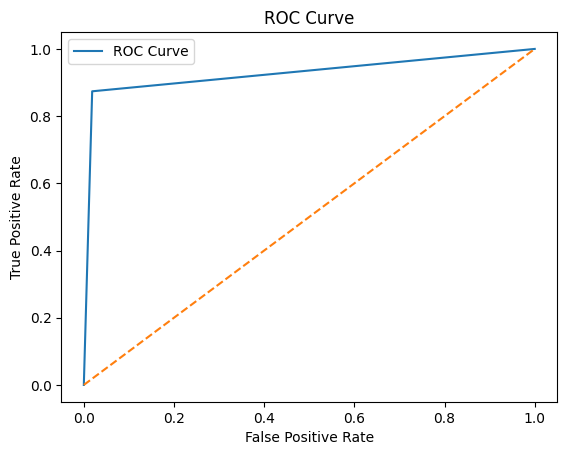

In [21]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Part E

In [22]:


# Create model
dt = DecisionTreeClassifier(random_state=42)

# Train model
dt.fit(X_train, y_train)

# Predict
y_pred = dt.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9771739130434782

Confusion Matrix:
[[800   9]
 [ 12  99]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       809
           1       0.92      0.89      0.90       111

    accuracy                           0.98       920
   macro avg       0.95      0.94      0.95       920
weighted avg       0.98      0.98      0.98       920



In [23]:
train_acc = dt.score(X_train, y_train)
test_acc = dt.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 1.0
Testing Accuracy: 0.9771739130434782


In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.9934782608695653


Part F


In [26]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_depth':[3,5,10,None],
    'min_samples_split':[2,5,10],
    'criterion':['gini','entropy']
}

random_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=5,
    cv=5,
    random_state=42
)

random_search.fit(X_train,y_train)

print(random_search.best_params_)
print(random_search.best_score_)

{'min_samples_split': 5, 'max_depth': 5, 'criterion': 'entropy'}
0.9730978260869566


In [27]:
param_dist = {
    'n_estimators':[50,100,200],
    'max_depth':[5,10,None],
    'min_samples_split':[2,5,10]
}

random_search_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=5,
    cv=5,
    random_state=42
)

random_search_rf.fit(X_train,y_train)

print(random_search_rf.best_params_)
print(random_search_rf.best_score_)

{'n_estimators': 50, 'min_samples_split': 5, 'max_depth': None}
0.9883152173913043


In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth':[3,5,10],
    'min_samples_split':[2,5],
    'criterion':['gini','entropy']
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5
)

grid.fit(X_train,y_train)

print(grid.best_params_)
print(grid.best_score_)

{'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 2}
0.9736413043478261


In [29]:
# Untuned
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)

# Tuned
best_dt = grid.best_estimator_

print("Untuned Accuracy :", dt.score(X_test,y_test))
print("Tuned Accuracy   :", best_dt.score(X_test,y_test))

Untuned Accuracy : 0.9771739130434782
Tuned Accuracy   : 0.9815217391304348
